# Fatigue Optimization Notebook v2 (Read Video Inference JSON)

This notebook implements a simple, interpretable **decision / optimization layer** for a driver fatigue intervention system.

It can now:
- read the JSON exported from the video inference notebook
- automatically build a real `MonitoringSession`
- combine video-derived probabilities with manual driver inputs
- output `video_risk`, `fatigue_score`, `risk_level`, `recommendation`, and `alert_level`

This notebook uses a **rule-based v1** approach so the logic stays easy to interpret and easy to modify.


## 1. Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict, Any


## 2. Session schema

In [2]:
@dataclass
class ManualInputs:
    driving_duration_min: float
    time_since_last_break_min: float

@dataclass
class VideoOutputs:
    time_points: List[float]
    drowsy_probability_sequence: List[float]

@dataclass
class MonitoringSession:
    session_id: str
    manual_inputs: ManualInputs
    video_outputs: VideoOutputs


## 3. Optional mock sessions (for comparison/debug)

In [3]:
low_risk_session = MonitoringSession(
    session_id='session_low',
    manual_inputs=ManualInputs(driving_duration_min=45, time_since_last_break_min=60),
    video_outputs=VideoOutputs(
        time_points=[i * 0.5 for i in range(20)],
        drowsy_probability_sequence=[0.08, 0.10, 0.12, 0.09, 0.11, 0.13, 0.10, 0.12, 0.11, 0.09,
                                    0.10, 0.12, 0.14, 0.13, 0.11, 0.10, 0.09, 0.12, 0.11, 0.10]
    )
)

medium_risk_session = MonitoringSession(
    session_id='session_medium',
    manual_inputs=ManualInputs(driving_duration_min=130, time_since_last_break_min=150),
    video_outputs=VideoOutputs(
        time_points=[i * 0.5 for i in range(20)],
        drowsy_probability_sequence=[0.15, 0.18, 0.20, 0.22, 0.24, 0.28, 0.30, 0.35, 0.38, 0.40,
                                    0.42, 0.45, 0.48, 0.50, 0.46, 0.44, 0.47, 0.49, 0.52, 0.55]
    )
)

high_risk_session = MonitoringSession(
    session_id='session_high',
    manual_inputs=ManualInputs(driving_duration_min=240, time_since_last_break_min=260),
    video_outputs=VideoOutputs(
        time_points=[i * 0.5 for i in range(20)],
        drowsy_probability_sequence=[0.45, 0.50, 0.58, 0.60, 0.65, 0.70, 0.72, 0.75, 0.78, 0.80,
                                    0.77, 0.79, 0.81, 0.83, 0.84, 0.82, 0.80, 0.79, 0.81, 0.85]
    )
)

mock_sessions = [low_risk_session, medium_risk_session, high_risk_session]


## 4. Local JSON path and manual input settings

In [5]:
# Edit this path to point to the JSON exported from your video inference notebook
VIDEO_INFERENCE_JSON_PATH = 'video_inference_outputs/video_probability_sequence_debug.json'

# Manual driver inputs for the real session
DRIVING_DURATION_MIN = 120
TIME_SINCE_LAST_BREAK_MIN = 150

print("VIDEO_INFERENCE_JSON_PATH:", VIDEO_INFERENCE_JSON_PATH)
print("JSON exists:", os.path.exists(VIDEO_INFERENCE_JSON_PATH))
print("DRIVING_DURATION_MIN:", DRIVING_DURATION_MIN)
print("TIME_SINCE_LAST_BREAK_MIN:", TIME_SINCE_LAST_BREAK_MIN)


VIDEO_INFERENCE_JSON_PATH: video_inference_outputs/video_probability_sequence_debug.json
JSON exists: True
DRIVING_DURATION_MIN: 120
TIME_SINCE_LAST_BREAK_MIN: 150


## 5. Plot helper

In [6]:
def plot_probability_sequence(session: MonitoringSession, title_suffix: str = ""):
    plt.figure(figsize=(8, 4))
    plt.plot(session.video_outputs.time_points, session.video_outputs.drowsy_probability_sequence)
    plt.xlabel('Time (s)')
    plt.ylabel('Drowsy Probability')
    plt.title(f"Drowsy Probability Curve - {session.session_id}{title_suffix}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()


## 6. Risk mapping functions

In [7]:
def smooth_sequence(probs: List[float], window: int = 3) -> np.ndarray:
    probs = np.array(probs, dtype=float)
    if len(probs) < window:
        return probs
    kernel = np.ones(window) / window
    padded = np.pad(probs, (window // 2, window // 2), mode='edge')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed[:len(probs)]

def map_video_risk(probs: List[float]) -> float:
    probs = np.array(probs, dtype=float)
    mean_prob = probs.mean()
    max_prob = probs.max()
    high_risk_ratio = (probs >= 0.6).mean()
    raw_score = 0.5 * mean_prob + 0.3 * max_prob + 0.2 * high_risk_ratio
    return float(np.clip(raw_score * 100, 0, 100))

def map_driving_duration_risk(driving_duration_min: float) -> float:
    if driving_duration_min <= 60:
        return 10
    elif driving_duration_min <= 120:
        return 25
    elif driving_duration_min <= 180:
        return 45
    elif driving_duration_min <= 240:
        return 65
    else:
        return 85

def map_break_gap_risk(time_since_last_break_min: float) -> float:
    if time_since_last_break_min <= 60:
        return 10
    elif time_since_last_break_min <= 120:
        return 25
    elif time_since_last_break_min <= 180:
        return 45
    elif time_since_last_break_min <= 240:
        return 65
    else:
        return 85


## 7. Fatigue score and decision logic

In [8]:
def compute_fatigue_score(video_risk: float, driving_duration_risk: float, break_gap_risk: float) -> float:
    score = 0.6 * video_risk + 0.2 * driving_duration_risk + 0.2 * break_gap_risk
    return float(np.clip(score, 0, 100))

def get_risk_level(fatigue_score: float) -> str:
    if fatigue_score <= 30:
        return 'low'
    elif fatigue_score <= 55:
        return 'medium'
    elif fatigue_score <= 75:
        return 'high'
    else:
        return 'critical'

def get_recommendation(risk_level: str) -> str:
    mapping = {
        'low': 'continue',
        'medium': 'stay_alert',
        'high': 'break_soon',
        'critical': 'break_now',
    }
    return mapping[risk_level]

def get_alert_level(risk_level: str) -> str:
    mapping = {
        'low': 'none',
        'medium': 'soft',
        'high': 'strong',
        'critical': 'urgent',
    }
    return mapping[risk_level]


## 8. Full session evaluation function

In [9]:
def evaluate_session(session: MonitoringSession, smoothing_window: int = 3) -> Dict[str, Any]:
    smoothed_probs = smooth_sequence(session.video_outputs.drowsy_probability_sequence, window=smoothing_window)
    video_risk = map_video_risk(smoothed_probs)
    driving_duration_risk = map_driving_duration_risk(session.manual_inputs.driving_duration_min)
    break_gap_risk = map_break_gap_risk(session.manual_inputs.time_since_last_break_min)
    fatigue_score = compute_fatigue_score(video_risk, driving_duration_risk, break_gap_risk)
    risk_level = get_risk_level(fatigue_score)
    recommendation = get_recommendation(risk_level)
    alert_level = get_alert_level(risk_level)

    return {
        'session_id': session.session_id,
        'driving_duration_min': session.manual_inputs.driving_duration_min,
        'time_since_last_break_min': session.manual_inputs.time_since_last_break_min,
        'video_risk': round(video_risk, 2),
        'driving_duration_risk': round(driving_duration_risk, 2),
        'break_gap_risk': round(break_gap_risk, 2),
        'fatigue_score': round(fatigue_score, 2),
        'risk_level': risk_level,
        'recommendation': recommendation,
        'alert_level': alert_level,
        'smoothed_probability_sequence': smoothed_probs,
    }


## 9. Load video inference JSON

In [10]:
with open(VIDEO_INFERENCE_JSON_PATH, "r", encoding="utf-8") as f:
    video_inference_payload = json.load(f)

video_inference_payload.keys()


dict_keys(['video_path', 'frame_interval_sec', 'use_face_crop', 'use_grayscale_3ch', 'time_points', 'drowsy_probability_sequence'])

## 10. Inspect JSON payload

In [11]:
video_inference_payload


{'video_path': 'test_video/test_video_4.mp4',
 'frame_interval_sec': 0.5,
 'use_face_crop': True,
 'use_grayscale_3ch': True,
 'time_points': [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5],
 'drowsy_probability_sequence': [0.2149573117494583,
  0.42698395252227783,
  0.9985575079917908,
  0.9999687671661377,
  0.9999973773956299,
  0.9999657869338989,
  0.9225391745567322,
  0.038701269775629044,
  0.003397350199520588,
  9.516359568806365e-06]}

## 11. Build real session from JSON + manual inputs

In [12]:
real_session_id = os.path.splitext(os.path.basename(video_inference_payload.get("video_path", "real_video_session")))[0]

real_session = MonitoringSession(
    session_id=real_session_id,
    manual_inputs=ManualInputs(
        driving_duration_min=DRIVING_DURATION_MIN,
        time_since_last_break_min=TIME_SINCE_LAST_BREAK_MIN,
    ),
    video_outputs=VideoOutputs(
        time_points=video_inference_payload["time_points"],
        drowsy_probability_sequence=video_inference_payload["drowsy_probability_sequence"],
    )
)

real_session


MonitoringSession(session_id='test_video_4', manual_inputs=ManualInputs(driving_duration_min=120, time_since_last_break_min=150), video_outputs=VideoOutputs(time_points=[0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5], drowsy_probability_sequence=[0.2149573117494583, 0.42698395252227783, 0.9985575079917908, 0.9999687671661377, 0.9999973773956299, 0.9999657869338989, 0.9225391745567322, 0.038701269775629044, 0.003397350199520588, 9.516359568806365e-06]))

## 12. Plot real session probability curve

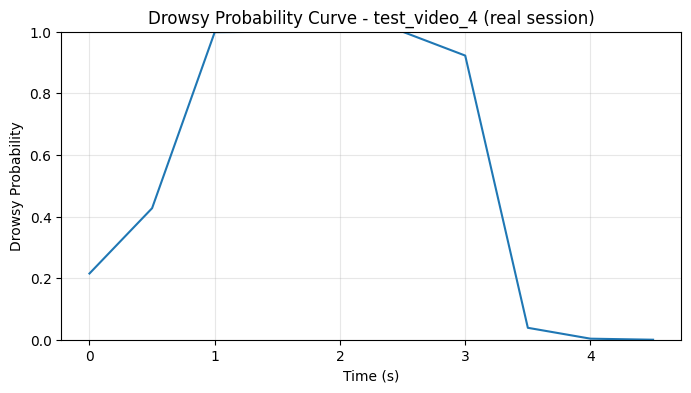

In [13]:
plot_probability_sequence(real_session, title_suffix=" (real session)")


## 13. Evaluate real session

In [14]:
real_result = evaluate_session(real_session)
real_result


{'session_id': 'test_video_4',
 'driving_duration_min': 120,
 'time_since_last_break_min': 150,
 'video_risk': 68.02,
 'driving_duration_risk': 25,
 'break_gap_risk': 45,
 'fatigue_score': 54.81,
 'risk_level': 'medium',
 'recommendation': 'stay_alert',
 'alert_level': 'soft',
 'smoothed_probability_sequence': array([0.28563286, 0.54683292, 0.80850341, 0.99950788, 0.99997731,
        0.97416745, 0.65373541, 0.32154593, 0.01403605, 0.00113879])}

## 14. Print real session decision summary

In [15]:
print("===== REAL SESSION RESULT =====")
print(f"session_id: {real_result['session_id']}")
print(f"driving_duration_min: {real_result['driving_duration_min']}")
print(f"time_since_last_break_min: {real_result['time_since_last_break_min']}")
print(f"video_risk: {real_result['video_risk']}")
print(f"driving_duration_risk: {real_result['driving_duration_risk']}")
print(f"break_gap_risk: {real_result['break_gap_risk']}")
print(f"fatigue_score: {real_result['fatigue_score']}")
print(f"risk_level: {real_result['risk_level']}")
print(f"recommendation: {real_result['recommendation']}")
print(f"alert_level: {real_result['alert_level']}")


===== REAL SESSION RESULT =====
session_id: test_video_4
driving_duration_min: 120
time_since_last_break_min: 150
video_risk: 68.02
driving_duration_risk: 25
break_gap_risk: 45
fatigue_score: 54.81
risk_level: medium
recommendation: stay_alert
alert_level: soft


## 15. Compare real session with mock sessions

In [16]:
comparison_sessions = mock_sessions + [real_session]
comparison_results = []

for session in comparison_sessions:
    result = evaluate_session(session)
    comparison_results.append({k: v for k, v in result.items() if k != 'smoothed_probability_sequence'})

comparison_df = pd.DataFrame(comparison_results)
comparison_df


,session_id,driving_duration_min,time_since_last_break_min,video_risk,driving_duration_risk,break_gap_risk,fatigue_score,risk_level,recommendation,alert_level
0,session_low,45,60,9.32,10,10,9.59,low,continue,none
1,session_medium,130,150,34.90,45,45,38.94,medium,stay_alert,soft
2,session_high,240,260,78.70,65,85,77.22,critical,break_now,urgent
3,test_video_4,120,150,68.02,25,45,54.81,medium,stay_alert,soft


## 16. Plot real session smoothed vs raw sequence

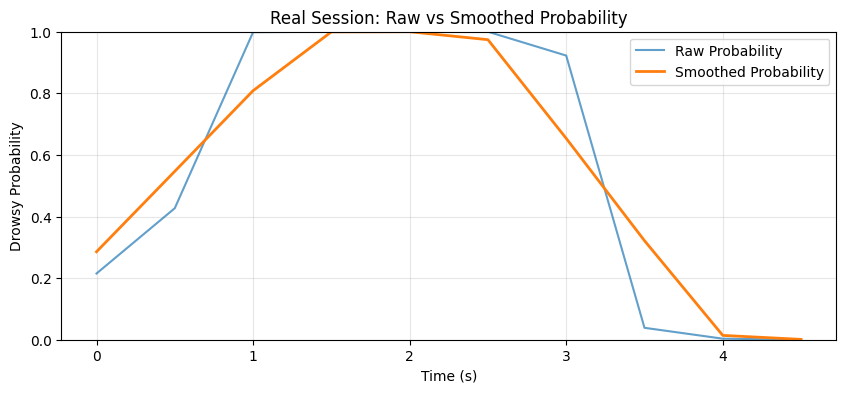

In [17]:
raw_probs = np.array(real_session.video_outputs.drowsy_probability_sequence)
smoothed_probs = np.array(real_result['smoothed_probability_sequence'])
time_points = np.array(real_session.video_outputs.time_points)

plt.figure(figsize=(10, 4))
plt.plot(time_points, raw_probs, label='Raw Probability', alpha=0.7)
plt.plot(time_points, smoothed_probs, label='Smoothed Probability', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Drowsy Probability')
plt.title('Real Session: Raw vs Smoothed Probability')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 17. Export real session optimization result

In [18]:
output_dir = os.path.dirname(VIDEO_INFERENCE_JSON_PATH) if os.path.dirname(VIDEO_INFERENCE_JSON_PATH) else '.'
result_json_path = os.path.join(output_dir, f"{real_session.session_id}_optimization_result.json")

export_result = {
    'session_id': real_result['session_id'],
    'manual_inputs': {
        'driving_duration_min': DRIVING_DURATION_MIN,
        'time_since_last_break_min': TIME_SINCE_LAST_BREAK_MIN,
    },
    'video_outputs': {
        'time_points': real_session.video_outputs.time_points,
        'drowsy_probability_sequence': real_session.video_outputs.drowsy_probability_sequence,
    },
    'decision_outputs': {
        'video_risk': real_result['video_risk'],
        'driving_duration_risk': real_result['driving_duration_risk'],
        'break_gap_risk': real_result['break_gap_risk'],
        'fatigue_score': real_result['fatigue_score'],
        'risk_level': real_result['risk_level'],
        'recommendation': real_result['recommendation'],
        'alert_level': real_result['alert_level'],
    }
}

with open(result_json_path, 'w', encoding='utf-8') as f:
    json.dump(export_result, f, indent=2)

print('Saved optimization result JSON to:', result_json_path)


Saved optimization result JSON to: video_inference_outputs\test_video_4_optimization_result.json


## 18. Notes for next step

You now have a full pipeline:

1. Local video inference notebook -> outputs `video_probability_sequence_debug.json`
2. This optimization notebook -> reads that JSON and generates fatigue decision outputs

Next step options:
- tune `map_video_risk()` if the score feels too low/high
- tune the weighting in `compute_fatigue_score()`
- tune the `risk_level` thresholds
- connect the final outputs to your app/demo frontend
